In [2]:
import numpy as np
import pandas as pd
import random
from chemevo import evolution_V1 as evo
import itertools
import os
import matplotlib.pyplot as plt
from chemevo import iterative_1D_method

fe_mg_bin_edges = np.arange(-0.35, 0.15, 0.1)
fe_mg_centers = 0.5 * (fe_mg_bin_edges[:-1] + fe_mg_bin_edges[1:])

In [3]:
data = pd.read_csv("data_lines_with_vals.csv")

In [4]:
# Default init values
alpha_cc_def = 0.4
alpha_Ia_def = 0.3
g_cc_def = 0.4
g_ratio_def = 1.8

In [5]:
alpha_cc_inits = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
alpha_Ia_inits = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
g_cc_inits = np.linspace(0.1, 1, 10)
#g_ratio_inits = np.linspace(1, 3, 15)
g_ratio_inits = [1, 1.3, 1.5, 1.7, 1.9, 2.1, 2.3, 2.5, 2.7, 2.9]

In [6]:
etas_bad =np.logspace(-2, 1, 10)
tau_stars_bad =np.linspace(0.5, 6, 10)

In [11]:
best_results_alpha_cc = []

# Loop for alpha_cc variations
for val in alpha_cc_inits:
    output_dir = f"models_with_mask_bad_range/alpha_cc_init_{val}/"
    os.makedirs(output_dir, exist_ok=True)
    
    iterative_1D_method.iterative_1D_loop(
        data_path="data_lines_with_vals.csv", 
        output_path=output_dir,
        n_iters=10, grid_size=0.1, grid_len=5, 
        alpha_cc_init=val, 
        alpha_Ia_init=alpha_Ia_def, 
        g_cc_init=g_cc_def, 
        g_ratio_init=g_ratio_def,
        etas = etas_bad,
        tau_stars=tau_stars_bad
    )
    
    # Read the results and extract the last row
    df_res = pd.read_csv(os.path.join(output_dir, "best_parameters_per_iteration.csv"))
    last_row = df_res.iloc[-1].copy()
    last_row['init_val_tested'] = val
    
    best_results_alpha_cc.append(last_row)

df_best_alpha_cc = pd.DataFrame(best_results_alpha_cc)

alpha_ccs =  [0.1 0.2 0.3]
n_gals in each alpha_cc =  300
n_gals total =  900
Done generating models for alpha_cc, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_cc, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_cc, iter = 0, grid size = 0.1, grid_len = 5
iter = 0
best alpha_cc = 0.3
alpha_Ias =  [0.1 0.2 0.3 0.4 0.5]
n_gals in each alpha_Ia =  300
n_gals total =  1500
Done generating models for alpha_Ia, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_Ia, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_Ia, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_Ia, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_Ia, iter = 0, grid size = 0.1, grid_len = 5
iter = 0
best alpha_Ia = 0.5
g_ccs =  [0.2 0.3 0.4 0.5 0.6]
n_gals in each g_cc =  300
n_gals total =  1500
Done generating models for g_cc, iter = 0, grid size = 0.1, grid_len = 5
Done gene

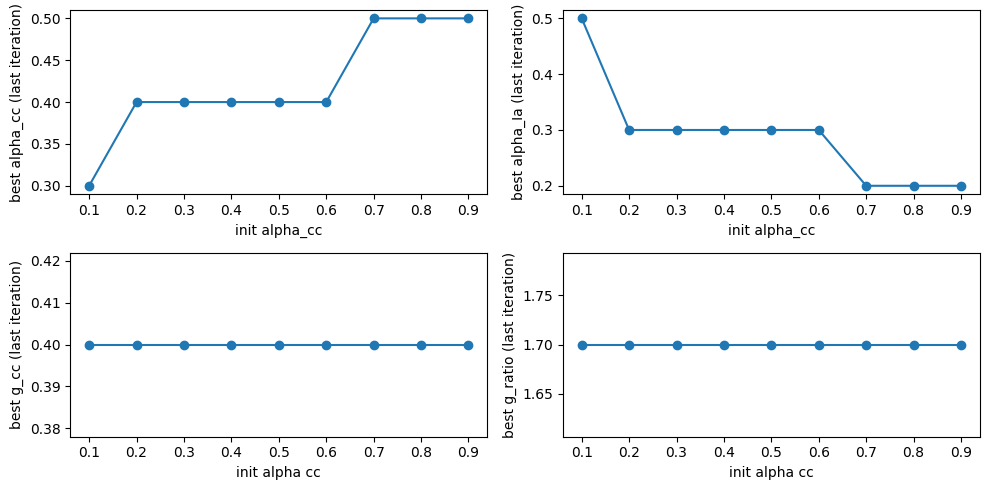

In [12]:
plt.figure(figsize=(10,5))

plt.subplot(2,2,1)
plt.plot(df_best_alpha_cc['init_val_tested'], df_best_alpha_cc['best_alpha_cc'], marker='o')
plt.xlabel("init alpha_cc")
plt.ylabel("best alpha_cc (last iteration)")

plt.subplot(2,2,2)
plt.plot(df_best_alpha_cc['init_val_tested'], df_best_alpha_cc['best_alpha_Ia'], marker='o')
plt.xlabel("init alpha_cc")
plt.ylabel("best alpha_Ia (last iteration)")

plt.subplot(2,2,3)
plt.plot(df_best_alpha_cc['init_val_tested'], df_best_alpha_cc['best_g_cc'], marker='o')
plt.xlabel("init alpha cc")
plt.ylabel("best g_cc (last iteration)")

plt.subplot(2,2,4)
plt.plot(df_best_alpha_cc['init_val_tested'], df_best_alpha_cc['best_g_ratio'], marker='o')
plt.xlabel("init alpha cc")
plt.ylabel("best g_ratio (last iteration)")


plt.tight_layout()

In [13]:
best_results_alpha_Ia = []

for val in alpha_Ia_inits:
    output_dir = f"models_with_mask_bad_range/alpha_Ia_init_{val}/"
    os.makedirs(output_dir, exist_ok=True)
    
    iterative_1D_method.iterative_1D_loop(
        data_path="data_lines_with_vals.csv", 
        output_path=output_dir,
        n_iters=10, grid_size=0.1, grid_len=5, 
        alpha_cc_init=alpha_cc_def, 
        alpha_Ia_init=val, 
        g_cc_init=g_cc_def, 
        g_ratio_init=g_ratio_def,
        etas = etas_bad,
        tau_stars=tau_stars_bad
    )
    
    # Read the results and extract the last row
    df_res = pd.read_csv(os.path.join(output_dir, "best_parameters_per_iteration.csv"))
    last_row = df_res.iloc[-1].copy()
    last_row['init_val_tested'] = val
    
    best_results_alpha_Ia.append(last_row)

df_best_alpha_Ia = pd.DataFrame(best_results_alpha_Ia)

alpha_ccs =  [0.2 0.3 0.4 0.5 0.6]
n_gals in each alpha_cc =  300
n_gals total =  1500
Done generating models for alpha_cc, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_cc, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_cc, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_cc, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_cc, iter = 0, grid size = 0.1, grid_len = 5
iter = 0
best alpha_cc = 0.5
alpha_Ias =  [0.1 0.2 0.3]
n_gals in each alpha_Ia =  300
n_gals total =  1500
Done generating models for alpha_Ia, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_Ia, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_Ia, iter = 0, grid size = 0.1, grid_len = 5
iter = 0
best alpha_Ia = 0.2
g_ccs =  [0.2 0.3 0.4 0.5 0.6]
n_gals in each g_cc =  300
n_gals total =  1500
Done generating models for g_cc, iter = 0, grid size = 0.1, grid_len = 5
Done gen

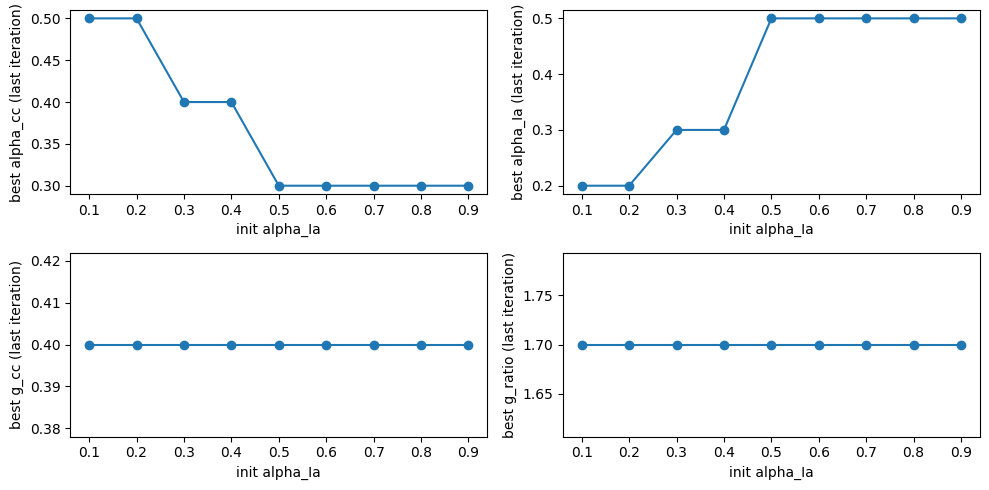

In [14]:
plt.figure(figsize=(10,5))

plt.subplot(2,2,1)
plt.plot(df_best_alpha_Ia['init_val_tested'], df_best_alpha_Ia['best_alpha_cc'], marker='o')
plt.xlabel("init alpha_Ia")
plt.ylabel("best alpha_cc (last iteration)")

plt.subplot(2,2,2)
plt.plot(df_best_alpha_Ia['init_val_tested'], df_best_alpha_Ia['best_alpha_Ia'], marker='o')
plt.xlabel("init alpha_Ia")
plt.ylabel("best alpha_Ia (last iteration)")

plt.subplot(2,2,3)
plt.plot(df_best_alpha_Ia['init_val_tested'], df_best_alpha_Ia['best_g_cc'], marker='o')
plt.xlabel("init alpha_Ia")
plt.ylabel("best g_cc (last iteration)")

plt.subplot(2,2,4)
plt.plot(df_best_alpha_Ia['init_val_tested'], df_best_alpha_Ia['best_g_ratio'], marker='o')
plt.xlabel("init alpha_Ia")
plt.ylabel("best g_ratio (last iteration)")


plt.tight_layout()

In [15]:
best_results_g_cc = []

for val in g_cc_inits:
    output_dir = f"models_with_mask_bad_range/g_cc_init_{val}/"
    os.makedirs(output_dir, exist_ok=True)
    
    iterative_1D_method.iterative_1D_loop(
        data_path="data_lines_with_vals.csv", 
        output_path=output_dir,
        n_iters=10, grid_size=0.1, grid_len=5, 
        alpha_cc_init=alpha_cc_def, 
        alpha_Ia_init=alpha_Ia_def, 
        g_cc_init=val, 
        g_ratio_init=g_ratio_def,
        etas = etas_bad,
        tau_stars=tau_stars_bad
    )
    
    # Read the results and extract the last row
    df_res = pd.read_csv(os.path.join(output_dir, "best_parameters_per_iteration.csv"))
    last_row = df_res.iloc[-1].copy()
    last_row['init_val_tested'] = val
    
    best_results_g_cc.append(last_row)

df_best_g_cc = pd.DataFrame(best_results_g_cc)

alpha_ccs =  [0.2 0.3 0.4 0.5 0.6]
n_gals in each alpha_cc =  300
n_gals total =  1500
Done generating models for alpha_cc, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_cc, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_cc, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_cc, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_cc, iter = 0, grid size = 0.1, grid_len = 5
iter = 0
best alpha_cc = 0.2
alpha_Ias =  [0.1 0.2 0.3 0.4 0.5]
n_gals in each alpha_Ia =  300
n_gals total =  1200
Done generating models for alpha_Ia, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_Ia, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_Ia, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_Ia, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_Ia, iter = 0, grid size = 0.1, grid_len = 5
iter = 0
best alpha_Ia = 0.

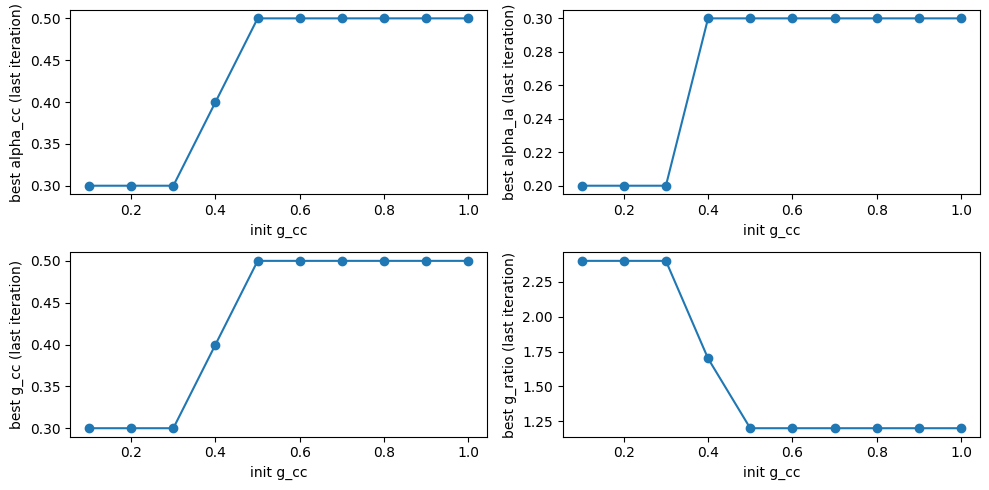

In [20]:
plt.figure(figsize=(10,5))

plt.subplot(2,2,1)
plt.plot(df_best_g_cc['init_val_tested'], df_best_g_cc['best_alpha_cc'], marker='o')
plt.xlabel("init g_cc")
plt.ylabel("best alpha_cc (last iteration)")

plt.subplot(2,2,2)
plt.plot(df_best_g_cc['init_val_tested'], df_best_g_cc['best_alpha_Ia'], marker='o')
plt.xlabel("init g_cc")
plt.ylabel("best alpha_Ia (last iteration)")

plt.subplot(2,2,3)
plt.plot(df_best_g_cc['init_val_tested'], df_best_g_cc['best_g_cc'], marker='o')
plt.xlabel("init g_cc")
plt.ylabel("best g_cc (last iteration)")

plt.subplot(2,2,4)
plt.plot(df_best_g_cc['init_val_tested'], df_best_g_cc['best_g_ratio'], marker='o')
plt.xlabel("init g_cc")
plt.ylabel("best g_ratio (last iteration)")


plt.tight_layout()

In [7]:
best_results_g_ratio = []

for val in g_ratio_inits:
    output_dir = f"models_with_mask_bad_range/g_ratio_init_{val}/"
    os.makedirs(output_dir, exist_ok=True)
    
    iterative_1D_method.iterative_1D_loop(
        data_path="data_lines_with_vals.csv", 
        output_path=output_dir,
        n_iters=10, grid_size=0.1, grid_len=5, 
        alpha_cc_init=alpha_cc_def, 
        alpha_Ia_init=alpha_Ia_def, 
        g_cc_init=g_cc_def, 
        g_ratio_init=val,
        etas = etas_bad,
        tau_stars=tau_stars_bad
    )
    
    # Read the results and extract the last row
    df_res = pd.read_csv(os.path.join(output_dir, "best_parameters_per_iteration.csv"))
    last_row = df_res.iloc[-1].copy()
    last_row['init_val_tested'] = val
    
    best_results_g_ratio.append(last_row)


df_best_g_ratio = pd.DataFrame(best_results_g_ratio)

alpha_ccs =  [0.2 0.3 0.4 0.5 0.6]
n_gals in each alpha_cc =  300
n_gals total =  1500
Done generating models for alpha_cc, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_cc, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_cc, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_cc, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_cc, iter = 0, grid size = 0.1, grid_len = 5
iter = 0
best alpha_cc = 0.3
alpha_Ias =  [0.1 0.2 0.3 0.4 0.5]
n_gals in each alpha_Ia =  300
n_gals total =  1500
Done generating models for alpha_Ia, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_Ia, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_Ia, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_Ia, iter = 0, grid size = 0.1, grid_len = 5
Done generating models for alpha_Ia, iter = 0, grid size = 0.1, grid_len = 5
iter = 0
best alpha_Ia = 0.

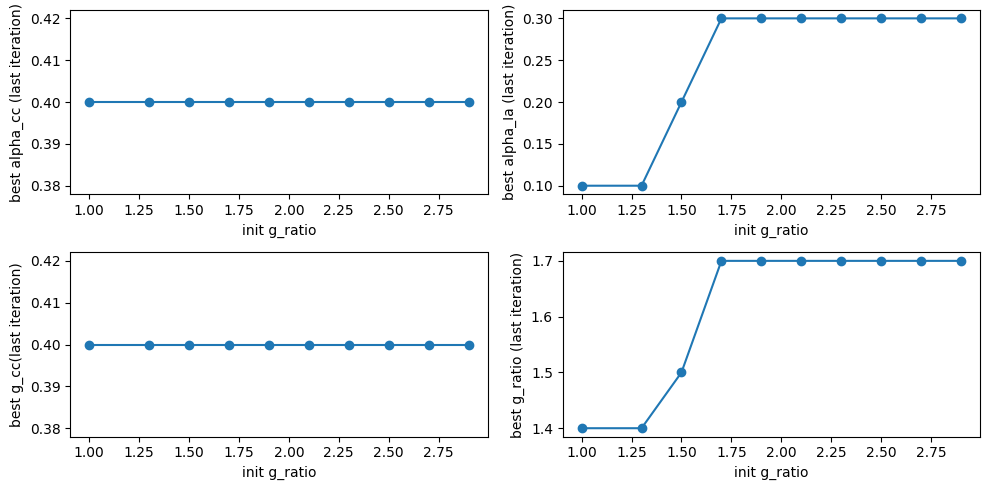

In [9]:
plt.figure(figsize=(10,5))

plt.subplot(2,2,1)
plt.plot(df_best_g_ratio['init_val_tested'], df_best_g_ratio['best_alpha_cc'], marker='o')
plt.xlabel("init g_ratio")
plt.ylabel("best alpha_cc (last iteration)")

plt.subplot(2,2,2)
plt.plot(df_best_g_ratio['init_val_tested'], df_best_g_ratio['best_alpha_Ia'], marker='o')
plt.xlabel("init g_ratio")
plt.ylabel("best alpha_Ia (last iteration)")

plt.subplot(2,2,3)
plt.plot(df_best_g_ratio['init_val_tested'], df_best_g_ratio['best_g_cc'], marker='o')
plt.xlabel("init g_ratio")
plt.ylabel("best g_cc(last iteration)")

plt.subplot(2,2,4)
plt.plot(df_best_g_ratio['init_val_tested'], df_best_g_ratio['best_g_ratio'], marker='o')
plt.xlabel("init g_ratio")
plt.ylabel("best g_ratio (last iteration)")


plt.tight_layout()